In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"bindupautrajyotibrat","key":"14a5bd9c1ec93a544d80563d3108408c"}'}

In [2]:
import os

os.makedirs('/root/.kaggle', exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

In [3]:
!kaggle datasets download -d jessicali9530/celeba-dataset
!unzip -q celeba-dataset.zip

Dataset URL: https://www.kaggle.com/datasets/jessicali9530/celeba-dataset
License(s): other
100% 1.33G/1.33G [00:07<00:00, 192MB/s]



In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader, random_split

from torch.amp import autocast, GradScaler

In [5]:
class CelebADataset(Dataset):
    def __init__(self, img_dir, transform=None):
        self.img_dir = img_dir
        self.image_names = sorted(os.listdir(img_dir))
        self.transform = transform

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.image_names[idx])
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image

In [6]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

dataset = CelebADataset("img_align_celeba/img_align_celeba", transform=transform)

dataset.image_names = dataset.image_names[:60000]

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

In [7]:
train_loader = DataLoader(
    train_dataset,
    batch_size=512,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    persistent_workers=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=512,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=False
)

In [8]:
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1),
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 512, 4, 2, 1),
            nn.ReLU()
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(512, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 3, 4, 2, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = Autoencoder().to(device).to(memory_format=torch.channels_last)

model = torch.compile(model)

criterion = nn.L1Loss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

scaler = GradScaler()

torch.backends.cudnn.benchmark = True

In [10]:
epochs = 50

for epoch in range(epochs):
    model.train()
    train_loss = 0

    for images in train_loader:
        images = images.to(device, non_blocking=True).to(memory_format=torch.channels_last)

        optimizer.zero_grad()

        with autocast(device_type='cuda'):
            outputs = model(images)
            loss = criterion(outputs, images)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    model.eval()
    val_loss = 0

    with torch.no_grad():
        for images in val_loader:
            images = images.to(device, non_blocking=True).to(memory_format=torch.channels_last)

            with autocast(device_type='cuda'):
                outputs = model(images)
                loss = criterion(outputs, images)

            val_loss += loss.item()

    val_loss /= len(val_loader)

    print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

W0329 16:57:08.126000 2943 torch/_inductor/utils.py:1679] [0/0] Not enough SMs to use max_autotune_gemm mode


Epoch [1/50] | Train Loss: 0.0919 | Val Loss: 0.0597
Epoch [2/50] | Train Loss: 0.0501 | Val Loss: 0.0452
Epoch [3/50] | Train Loss: 0.0440 | Val Loss: 0.0404
Epoch [4/50] | Train Loss: 0.0374 | Val Loss: 0.0364
Epoch [5/50] | Train Loss: 0.0334 | Val Loss: 0.0356
Epoch [6/50] | Train Loss: 0.0320 | Val Loss: 0.0294
Epoch [7/50] | Train Loss: 0.0309 | Val Loss: 0.0334
Epoch [8/50] | Train Loss: 0.0285 | Val Loss: 0.0284
Epoch [9/50] | Train Loss: 0.0277 | Val Loss: 0.0283
Epoch [10/50] | Train Loss: 0.0268 | Val Loss: 0.0252
Epoch [11/50] | Train Loss: 0.0261 | Val Loss: 0.0258
Epoch [12/50] | Train Loss: 0.0244 | Val Loss: 0.0239
Epoch [13/50] | Train Loss: 0.0248 | Val Loss: 0.0315
Epoch [14/50] | Train Loss: 0.0241 | Val Loss: 0.0234
Epoch [15/50] | Train Loss: 0.0239 | Val Loss: 0.0288
Epoch [16/50] | Train Loss: 0.0222 | Val Loss: 0.0219
Epoch [17/50] | Train Loss: 0.0233 | Val Loss: 0.0237
Epoch [18/50] | Train Loss: 0.0226 | Val Loss: 0.0246
Epoch [19/50] | Train Loss: 0.0227 | 

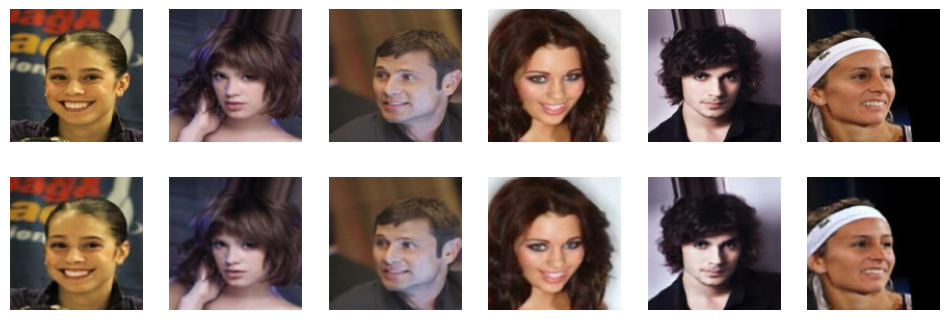

In [11]:
dataiter = iter(val_loader)
images = next(dataiter).to(device)

with torch.no_grad():
    outputs = model(images)

images = images.cpu().numpy()
outputs = outputs.cpu().numpy()

fig, axes = plt.subplots(2, 6, figsize=(12,4))

for i in range(6):
    axes[0, i].imshow(np.transpose(images[i], (1,2,0)))
    axes[0, i].axis('off')

    axes[1, i].imshow(np.transpose(outputs[i], (1,2,0)))
    axes[1, i].axis('off')

plt.show()

In [12]:
!pip install pytorch-msssim

In [14]:
loss = criterion(outputs, images)

In [15]:
import torch

def calculate_psnr(original, reconstructed):
    mse = torch.mean((original - reconstructed) ** 2)
    if mse == 0:
        return 100
    psnr = 20 * torch.log10(1.0 / torch.sqrt(mse))
    return psnr

In [16]:
from pytorch_msssim import ssim

model.eval()

total_psnr = 0
total_ssim = 0
count = 0

with torch.no_grad():
    for images in val_loader:
        images = images.to(device)
        outputs = model(images)

        total_psnr += calculate_psnr(images, outputs).item()
        total_ssim += ssim(images, outputs, data_range=1.0, size_average=True).item()
        count += 1

print("Average PSNR:", total_psnr / count)
print("Average SSIM:", total_ssim / count)

Average PSNR: 31.126471439997356
Average SSIM: 0.9329655667146047


In [43]:
from google.colab import files
uploaded = files.upload()

Saving tom.jpg to tom.jpg


In [44]:
from PIL import Image

img_path = list(uploaded.keys())[0]

image = Image.open(img_path).convert('RGB')

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

input_image = transform(image).unsqueeze(0).to(device)

In [45]:
model.eval()

with torch.no_grad():
    output_image = model(input_image)

In [46]:
input_np = input_image.squeeze().cpu().numpy()
output_np = output_image.squeeze().cpu().numpy()

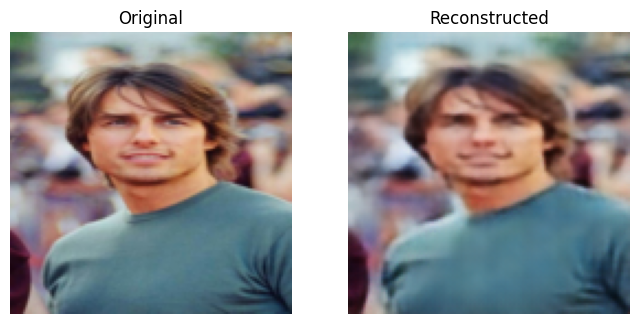

In [47]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(8,4))

axes[0].imshow(input_np.transpose(1,2,0))
axes[0].set_title("Original")
axes[0].axis('off')

axes[1].imshow(output_np.transpose(1,2,0))
axes[1].set_title("Reconstructed")
axes[1].axis('off')

plt.show()

In [23]:
torch.save(model.state_dict(), "autoencoder_celeba.pth")

In [24]:
torch.save(model, "autoencoder_full.pth")

In [25]:
from google.colab import files
files.download("autoencoder_celeba.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [48]:
state_dict = torch.load("autoencoder_celeba.pth")

new_state_dict = {}
for k, v in state_dict.items():
    new_key = k.replace("_orig_mod.", "")
    new_state_dict[new_key] = v

model = Autoencoder().to(device)
model.load_state_dict(new_state_dict)
model.eval()

Autoencoder(
  (encoder): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): ReLU()
    (5): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (6): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU()
    (8): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (9): ReLU()
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
 

In [28]:
model.load_state_dict(torch.load("autoencoder_celeba.pth"), strict=False)

_IncompatibleKeys(missing_keys=['encoder.0.weight', 'encoder.0.bias', 'encoder.2.weight', 'encoder.2.bias', 'encoder.3.weight', 'encoder.3.bias', 'encoder.3.running_mean', 'encoder.3.running_var', 'encoder.5.weight', 'encoder.5.bias', 'encoder.6.weight', 'encoder.6.bias', 'encoder.6.running_mean', 'encoder.6.running_var', 'encoder.8.weight', 'encoder.8.bias', 'decoder.0.weight', 'decoder.0.bias', 'decoder.1.weight', 'decoder.1.bias', 'decoder.1.running_mean', 'decoder.1.running_var', 'decoder.3.weight', 'decoder.3.bias', 'decoder.4.weight', 'decoder.4.bias', 'decoder.4.running_mean', 'decoder.4.running_var', 'decoder.6.weight', 'decoder.6.bias', 'decoder.8.weight', 'decoder.8.bias'], unexpected_keys=['_orig_mod.encoder.0.weight', '_orig_mod.encoder.0.bias', '_orig_mod.encoder.2.weight', '_orig_mod.encoder.2.bias', '_orig_mod.encoder.3.weight', '_orig_mod.encoder.3.bias', '_orig_mod.encoder.3.running_mean', '_orig_mod.encoder.3.running_var', '_orig_mod.encoder.3.num_batches_tracked', '_

In [29]:
import os

project_dir = "celeba-autoencoder"
os.makedirs(project_dir, exist_ok=True)

In [30]:
model_code = """
import torch
import torch.nn as nn

class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1),
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 512, 4, 2, 1),
            nn.ReLU()
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(512, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 3, 4, 2, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))
"""

with open(f"{project_dir}/model.py", "w") as f:
    f.write(model_code)

In [31]:
inference_code = """
import torch
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import sys

from model import Autoencoder

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = Autoencoder().to(device)

state_dict = torch.load("autoencoder_celeba.pth", map_location=device)

# Fix for torch.compile prefix
new_state_dict = {k.replace("_orig_mod.", ""): v for k, v in state_dict.items()}

model.load_state_dict(new_state_dict)
model.eval()

image_path = sys.argv[1]

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

image = Image.open(image_path).convert("RGB")
input_tensor = transform(image).unsqueeze(0).to(device)

with torch.no_grad():
    output = model(input_tensor)

input_np = input_tensor.squeeze().cpu().numpy()
output_np = output.squeeze().cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(8,4))

axes[0].imshow(input_np.transpose(1,2,0))
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(output_np.transpose(1,2,0))
axes[1].set_title("Reconstructed")
axes[1].axis("off")

plt.show()
"""

with open(f"{project_dir}/inference.py", "w") as f:
    f.write(inference_code)

In [32]:
requirements = """torch
torchvision
pillow
matplotlib
pytorch-msssim
"""

with open(f"{project_dir}/requirements.txt", "w") as f:
    f.write(requirements)

In [34]:
readme = """
# CelebA Autoencoder

## Overview
This project implements a Convolutional Autoencoder trained on the CelebA dataset for image compression and reconstruction.

## Features
- Learns compressed latent representation of face images
- Reconstructs images from compressed representation
- Evaluated using PSNR and SSIM metrics

## Dataset
- CelebA Dataset (Kaggle)

## Model
- Encoder: Convolutional layers with downsampling
- Decoder: Transposed convolution layers for reconstruction

## Results
- PSNR: ~31 dB
- SSIM: ~0.93

## Usage

### Run Inference
```bash
python inference.py path_to_image.jpg

Notes
Model performs lossy compression
Some blurring is expected due to reconstruction loss
Author

Autoencoder project for Deep Learning experiment
"""

with open(f"{project_dir}/README.md", "w") as f:
  f.write(readme)

In [35]:
import shutil

shutil.copy("autoencoder_celeba.pth", f"{project_dir}/autoencoder_celeba.pth")

'celeba-autoencoder/autoencoder_celeba.pth'

In [36]:
shutil.make_archive("celeba-autoencoder", 'zip', project_dir)

'/content/celeba-autoencoder.zip'

In [37]:
from google.colab import files
files.download("celeba-autoencoder.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>